# Analyze Weights

Diagnostic notebook for inspecting one or more BlueRecording weights files.

- **Single file:** validates structure, shows weight distributions per electrode broken down by section type.
- **Multiple files:** regression comparison — checks matching structure, compares scaling factors.

In [1]:
# === Parameters (edit these) ===

# List of paths to weights H5 files. At least one required.
WEIGHTS_FILES = [
    "../examples/single_cell_l5_tpc/reference/weights_near_ref.h5",
    "../removeme/weights.h5"
]

# Histogram settings — auto-computed by default, override if needed.
N_BINS = None          # Number of bins (None = auto via Freedman-Diaconis)
HIST_RANGE = None      # Tuple (min, max) or None for auto
LOG_SCALE = True       # Log-scale y-axis for histograms

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import PurePosixPath
from neurodamus.metype import BaseCell

assert len(WEIGHTS_FILES) >= 1, "Provide at least one weights file"

# Build section-type name map from neurodamus (auto-tracks any future changes)
SECTION_TYPE_NAMES = {idx: st for idx, (st, _) in enumerate(BaseCell.SECTION_TYPES)}

def _auto_labels(paths):
    """Extract labels from the parts of the paths that differ."""
    split = [PurePosixPath(p).parts for p in paths]
    prefix = 0
    for parts in zip(*split):
        if len(set(parts)) == 1:
            prefix += 1
        else:
            break
    suffix = 0
    for parts in zip(*(s[::-1] for s in split)):
        if len(set(parts)) == 1:
            suffix += 1
        else:
            break
    labels = []
    for s in split:
        end = len(s) - suffix if suffix else len(s)
        diff = s[prefix:end]
        labels.append("/".join(diff) if diff else str(s[-1]))
    return labels

LABELS = _auto_labels(WEIGHTS_FILES) if len(WEIGHTS_FILES) > 1 else [None]

In [3]:
# --- Load all files ---

def load_weights(path):
    """Load a weights H5 file and return a dict with its contents."""
    h5 = h5py.File(path, "r")
    pop_name = None
    for key in h5.keys():
        if key != "electrodes" and "node_ids" in h5[key]:
            pop_name = key
            break
    assert pop_name is not None, f"Cannot find population in {path}"

    node_ids = h5[f"{pop_name}/node_ids"][:]
    offsets = h5[f"{pop_name}/offsets"][:]
    sf = h5[f"electrodes/{pop_name}/scaling_factors"][:]

    neurite_types = None
    if f"{pop_name}/neurite_types" in h5:
        neurite_types = h5[f"{pop_name}/neurite_types"][:]

    electrode_names = sorted(
        [k for k in h5["electrodes"].keys() if k != pop_name],
        key=lambda x: int(x) if x.isdigit() else x,
    )

    h5.close()

    return {
        "path": path,
        "pop_name": pop_name,
        "node_ids": node_ids,
        "offsets": offsets,
        "scaling_factors": sf,
        "neurite_types": neurite_types,
        "electrode_names": electrode_names,
    }

data = [load_weights(p) for p in WEIGHTS_FILES]
print(f"Loaded {len(data)} file(s)")

Loaded 2 file(s)


In [4]:
# --- Validation & cross-file checks ---

def validate(d, label):
    """Check internal consistency of a single weights file."""
    n_nodes = len(d["node_ids"])
    n_offsets = len(d["offsets"])
    n_compartments = d["scaling_factors"].shape[0]
    n_electrodes = d["scaling_factors"].shape[1] - 1

    tag = f"[{label}] " if label else ""
    print(f"\n{tag}{d['path']}")
    print(f"  Population:    {d['pop_name']}")
    print(f"  Nodes:         {n_nodes}")
    print(f"  Compartments:  {n_compartments}")
    print(f"  Electrodes:    {n_electrodes}")

    # offsets is CSR-style: length == n_nodes + 1
    assert n_offsets == n_nodes + 1, (
        f"offsets length ({n_offsets}) != node_ids length + 1 ({n_nodes + 1})"
    )
    assert np.all(np.diff(d["offsets"]) > 0), "offsets not strictly increasing"
    assert d["offsets"][-1] == n_compartments, (
        f"last offset ({d['offsets'][-1]}) != n_compartments ({n_compartments})"
    )

    if d["neurite_types"] is not None:
        n_nt = len(d["neurite_types"])
        assert n_nt == n_compartments, (
            f"neurite_types length ({n_nt}) != n_compartments ({n_compartments})"
        )
        unique_types = np.unique(d["neurite_types"])
        print(f"  Neurite types: {unique_types}")
    else:
        print("  Neurite types: not present")

    print("  Validation:    OK")

for d, label in zip(data, LABELS):
    validate(d, label)

# Cross-file checks (when multiple files)
if len(data) >= 2:
    ref = data[0]
    for d, label in zip(data[1:], LABELS[1:]):
        assert np.array_equal(ref["node_ids"], d["node_ids"]), (
            f"node_ids mismatch between {LABELS[0]} and {label}"
        )
        assert np.array_equal(ref["offsets"], d["offsets"]), (
            f"offsets mismatch between {LABELS[0]} and {label}"
        )
        assert ref["scaling_factors"].shape == d["scaling_factors"].shape, (
            f"scaling_factors shape mismatch: "
            f"{ref['scaling_factors'].shape} vs {d['scaling_factors'].shape}"
        )
    print("\nCross-file structure check: OK")

# Resolve shared neurite_types: use from whichever file(s) have it,
# verify they match if multiple do, then assign to all.
nt_sources = [(d, label) for d, label in zip(data, LABELS) if d["neurite_types"] is not None]

SHARED_NEURITE_TYPES = None
if nt_sources:
    SHARED_NEURITE_TYPES = nt_sources[0][0]["neurite_types"]
    for d, label in nt_sources[1:]:
        assert np.array_equal(SHARED_NEURITE_TYPES, d["neurite_types"]), (
            f"neurite_types mismatch between {nt_sources[0][1]} and {label}"
        )
    # Assign to files that don't have it (lengths already validated to match)
    for d in data:
        if d["neurite_types"] is None:
            d["neurite_types"] = SHARED_NEURITE_TYPES
    print(f"Shared neurite_types resolved from {len(nt_sources)} file(s), applied to all {len(data)}")
else:
    print("No files contain neurite_types")


[examples/single_cell_l5_tpc/reference/weights_near_ref.h5] ../examples/single_cell_l5_tpc/reference/weights_near_ref.h5
  Population:    S1nonbarrel_neurons
  Nodes:         1
  Compartments:  1099
  Electrodes:    6
  Neurite types: not present
  Validation:    OK

[removeme/weights.h5] ../removeme/weights.h5
  Population:    S1nonbarrel_neurons
  Nodes:         1
  Compartments:  1099
  Electrodes:    6
  Neurite types: [0 1 2 3 6]
  Validation:    OK

Cross-file structure check: OK
Shared neurite_types resolved from 1 file(s), applied to all 2


In [5]:
# --- Histogram helpers ---

def auto_bins(values, n_bins=None, hist_range=None):
    """Compute bin edges using Freedman-Diaconis rule, or use overrides."""
    if hist_range is None:
        hist_range = (np.nanmin(values), np.nanmax(values))
    if n_bins is not None:
        return np.linspace(hist_range[0], hist_range[1], n_bins + 1)
    q75, q25 = np.nanpercentile(values, [75, 25])
    iqr = q75 - q25
    n = len(values)
    if iqr == 0 or n == 0:
        return np.linspace(hist_range[0], hist_range[1], 51)
    bin_width = 2.0 * iqr * n ** (-1.0 / 3.0)
    n_auto = max(1, int(np.ceil((hist_range[1] - hist_range[0]) / bin_width)))
    n_auto = min(n_auto, 200)
    return np.linspace(hist_range[0], hist_range[1], n_auto + 1)

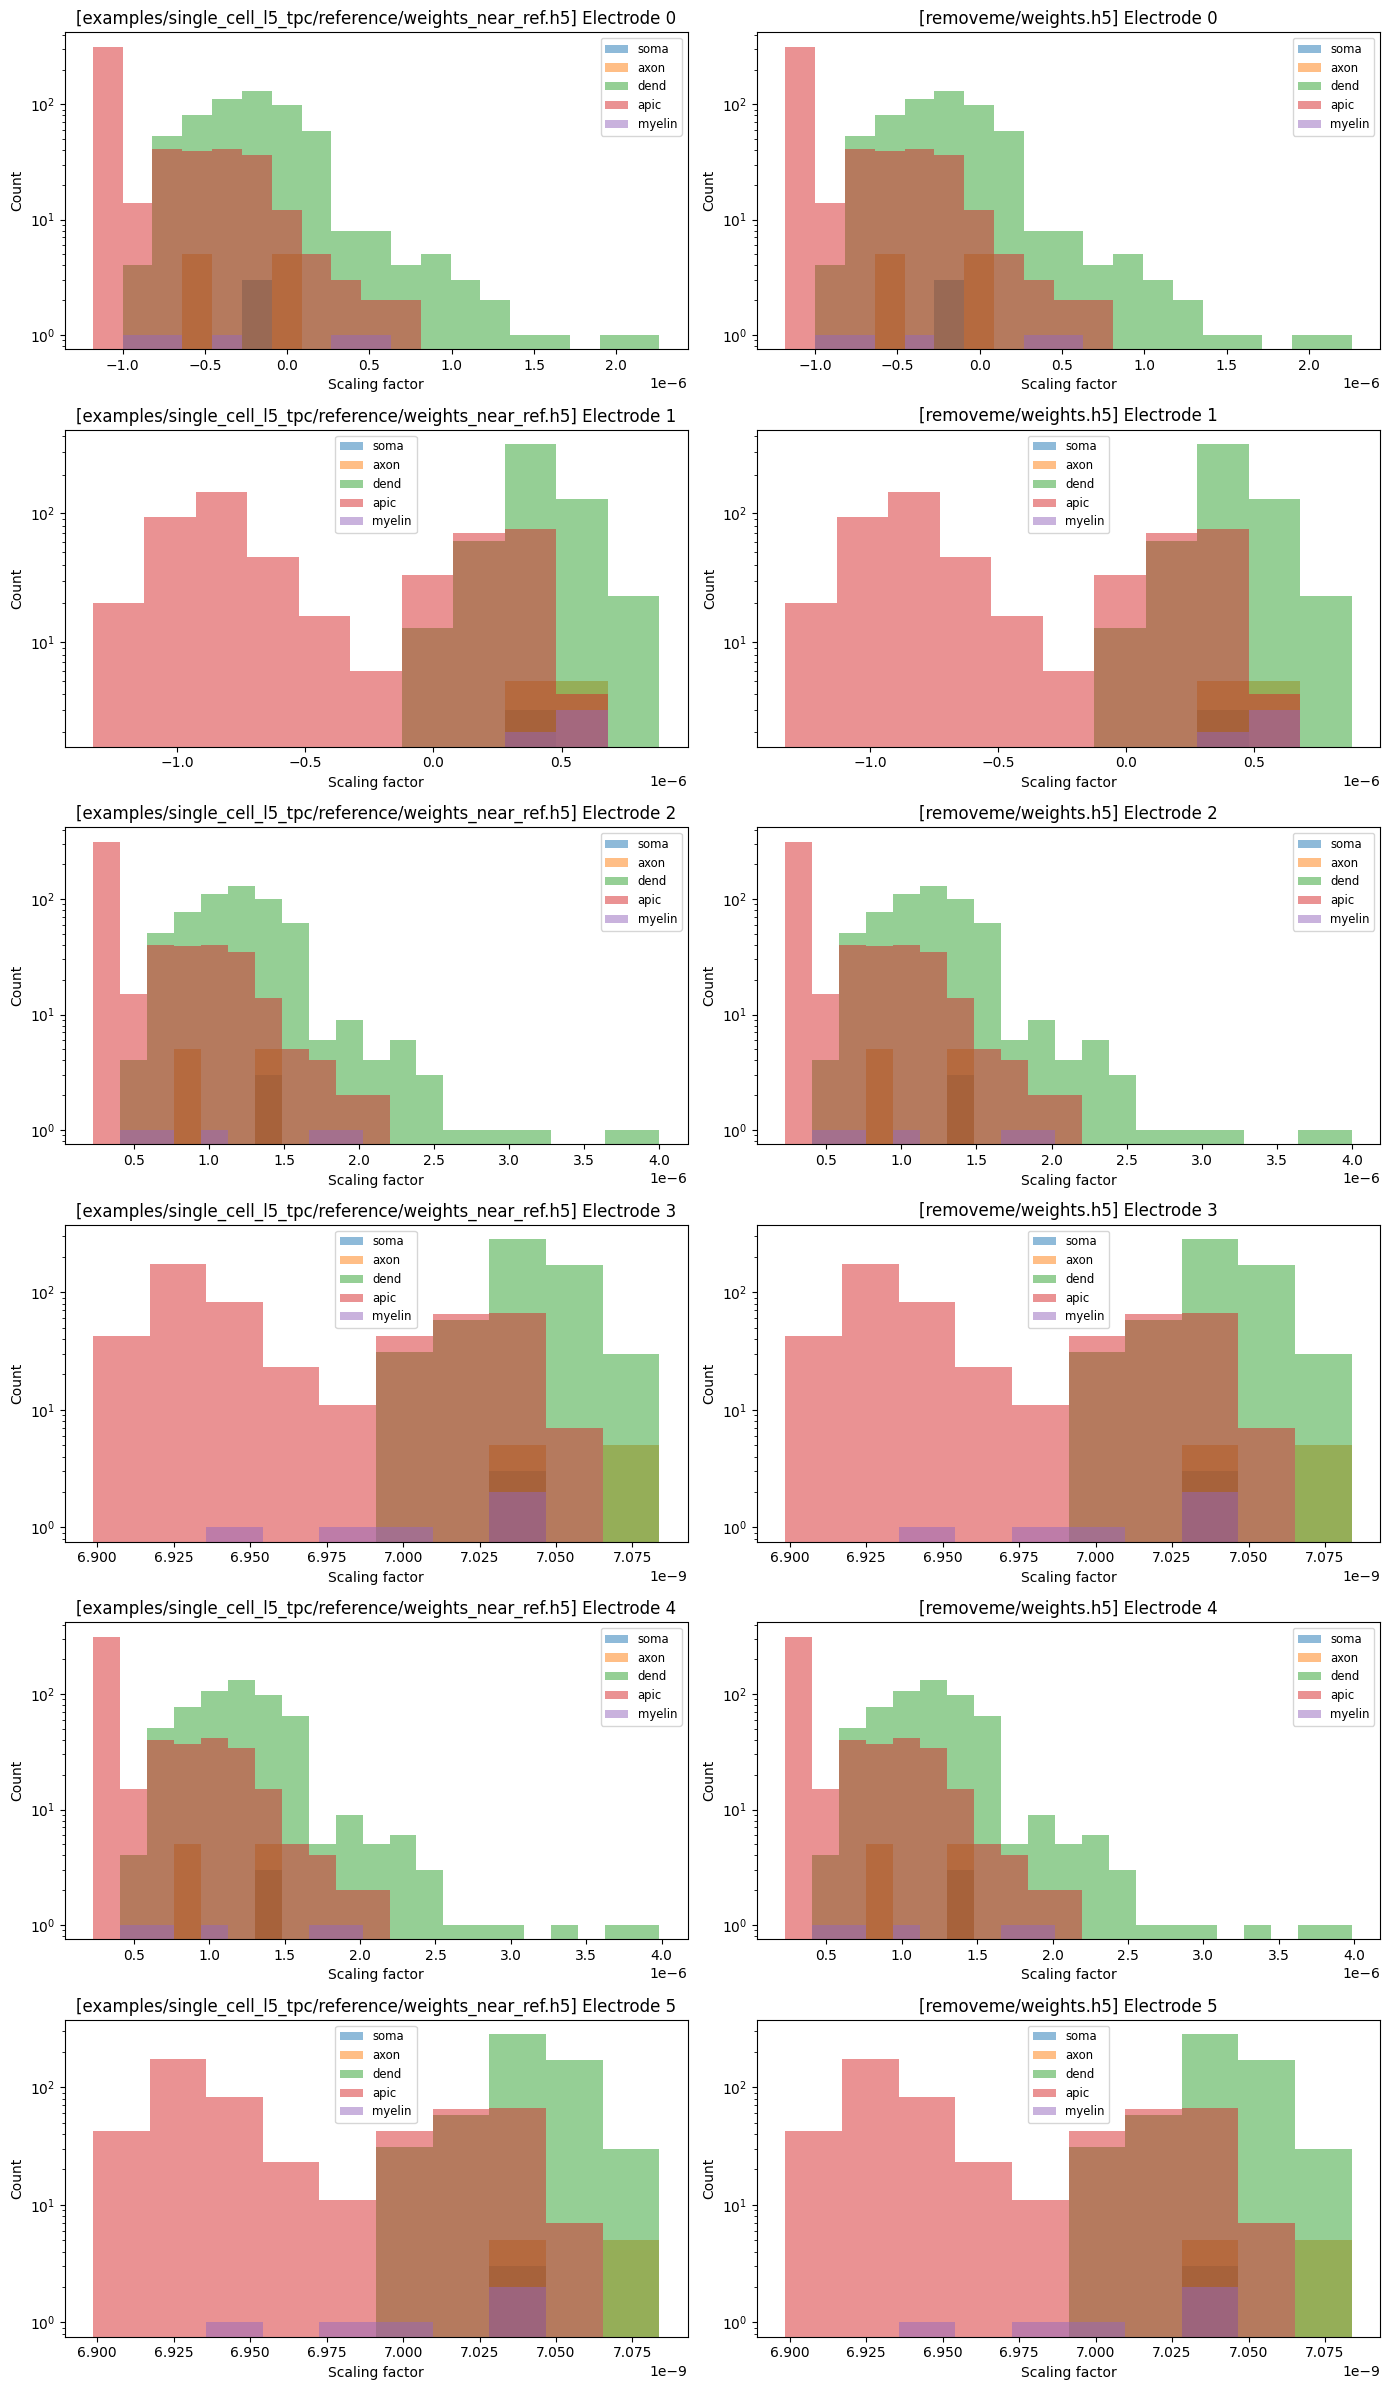

In [6]:
# --- Per section-type breakdown ---
# Table of histograms: rows = electrodes, columns = weights files.
# Each subplot shows the weight distribution broken down by section type.

if SHARED_NEURITE_TYPES is None:
    print("No neurite_types available — skipping section-type breakdown")
else:
    n_files = len(data)
    n_electrodes = data[0]["scaling_factors"].shape[1] - 1

    fig, axes = plt.subplots(
        n_electrodes, n_files,
        figsize=(7 * n_files, 4 * n_electrodes),
        squeeze=False,
    )

    for col_idx, (d, label) in enumerate(zip(data, LABELS)):
        nt = d["neurite_types"]
        sf = d["scaling_factors"]
        unique_types = np.unique(nt)

        for row_idx in range(n_electrodes):
            ax = axes[row_idx, col_idx]
            all_vals = sf[:, row_idx]
            bins = auto_bins(all_vals, n_bins=N_BINS, hist_range=HIST_RANGE)

            for t in unique_types:
                mask = nt == t
                t_name = SECTION_TYPE_NAMES.get(t, f"type_{t}")
                ax.hist(sf[mask, row_idx], bins=bins, alpha=0.5, label=t_name)

            e_name = d["electrode_names"][row_idx] if row_idx < len(d["electrode_names"]) else str(row_idx)

            title = f"Electrode {e_name}"
            if label is not None:
                title = f"[{label}] {title}"
            ax.set_title(title)
            ax.set_xlabel("Scaling factor")
            ax.set_ylabel("Count")
            if LOG_SCALE:
                ax.set_yscale("log")
            ax.legend(fontsize="small")

    plt.tight_layout()
    plt.show()

In [ ]:
# --- Regression comparison (only if multiple files) ---

if len(data) >= 2:
    ref = data[0]
    for d, label in zip(data[1:], LABELS[1:]):
        diff = d["scaling_factors"] - ref["scaling_factors"]
        sf_ref = ref["scaling_factors"]
        with np.errstate(divide="ignore", invalid="ignore"):
            rel_diff = np.where(sf_ref != 0, diff / np.abs(sf_ref), 0.0)

        print(f"\n--- {LABELS[0]} vs {label} ---")
        print(f"  Max abs diff:  {np.max(np.abs(diff)):.6e}")
        print(f"  Mean abs diff: {np.mean(np.abs(diff)):.6e}")
        print(f"  Max rel diff:  {np.max(np.abs(rel_diff)):.6e}")

        for e_idx in range(diff.shape[1] - 1):
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))

            e_name = ref["electrode_names"][e_idx] if e_idx < len(ref["electrode_names"]) else str(e_idx)

            d_col = diff[:, e_idx]
            bins_abs = auto_bins(d_col)
            axes[0].hist(d_col, bins=bins_abs, alpha=0.7)
            axes[0].set_title(f"Electrode {e_name} — abs diff")
            axes[0].set_xlabel(f"{label} - {LABELS[0]}")
            axes[0].set_ylabel("Count")
            if LOG_SCALE:
                axes[0].set_yscale("log")

            r_col = rel_diff[:, e_idx]
            bins_rel = auto_bins(r_col)
            axes[1].hist(r_col, bins=bins_rel, alpha=0.7, color="orange")
            axes[1].set_title(f"Electrode {e_name} — rel diff")
            axes[1].set_xlabel(f"({label} - {LABELS[0]}) / |{LABELS[0]}|")
            axes[1].set_ylabel("Count")
            if LOG_SCALE:
                axes[1].set_yscale("log")

            plt.tight_layout()
            plt.show()
else:
    print("Single file — skipping regression comparison")